In [44]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [45]:
data= pd.read_csv(r'Dataset/WA_Fn-UseC_-Telco-Customer-Churn-selected-columns.csv')

In [46]:
data=data.copy()

In [47]:
data.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,DeviceProtection,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
2757,Female,0,Yes,Yes,69,Yes,Fiber optic,Yes,Yes,No,No,One year,Bank transfer (automatic),No
6763,Male,1,Yes,Yes,71,Yes,DSL,No,Yes,No,Yes,One year,Bank transfer (automatic),No
5457,Female,0,Yes,Yes,11,Yes,DSL,Yes,No,No,No,Month-to-month,Bank transfer (automatic),No
4123,Male,1,Yes,No,34,Yes,Fiber optic,No,No,No,No,Month-to-month,Credit card (automatic),No
2417,Male,0,No,No,10,No,DSL,No,No,No,No,Month-to-month,Electronic check,No


In [48]:
data['Contract'].value_counts(), data['Partner'].value_counts(), data['InternetService'].value_counts()

(Contract
 Month-to-month    3875
 Two year          1695
 One year          1473
 Name: count, dtype: int64,
 Partner
 No     3641
 Yes    3402
 Name: count, dtype: int64,
 InternetService
 Fiber optic    3096
 DSL            2421
 No             1526
 Name: count, dtype: int64)

In [49]:
data['tenure']=data['tenure'].replace(0, data['tenure'].mean())
data['SeniorCitizen']=data['SeniorCitizen'].replace({1:'Yes', 0:'No'})

In [50]:
data.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,DeviceProtection,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
3702,Female,Yes,No,No,20.0,Yes,Fiber optic,Yes,No,No,No,Month-to-month,Electronic check,Yes
195,Female,No,Yes,No,20.0,Yes,Fiber optic,Yes,No,Yes,No,Month-to-month,Electronic check,No
3574,Female,No,No,No,1.0,Yes,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,Mailed check,No
65,Female,No,No,No,3.0,Yes,DSL,No,No,Yes,Yes,Month-to-month,Electronic check,No
1535,Male,Yes,Yes,No,7.0,Yes,DSL,Yes,No,No,No,Month-to-month,Electronic check,No


In [51]:
data[['OnlineSecurity','DeviceProtection','StreamingTV','StreamingMovies']]=data[['OnlineSecurity','DeviceProtection','StreamingTV','StreamingMovies']].replace('No internet service','No')


<Axes: xlabel='tenure', ylabel='Count'>

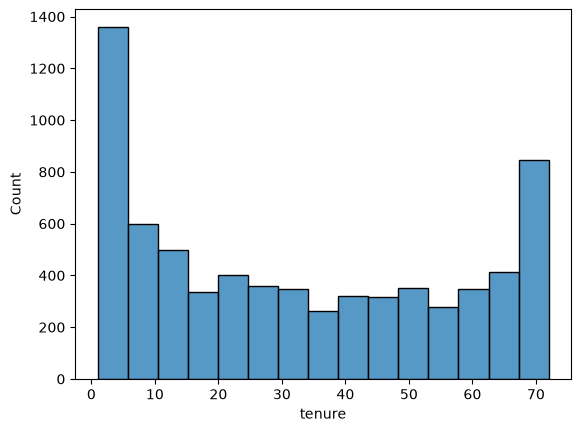

In [52]:
sns.histplot(data['tenure'])

In [53]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [54]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(data.drop('Churn', axis=1), data['Churn'], test_size=0.2, random_state=0)

In [55]:
trnf1= ColumnTransformer([('one-hot', OneHotEncoder(drop='first'), list(range(0,4))+list(range(5,13))), ('power', PowerTransformer(method='yeo-johnson'), [4])], remainder='passthrough')

In [56]:
x_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'InternetService', 'OnlineSecurity', 'DeviceProtection',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='str')

In [57]:
le= LabelEncoder()

y_train_trns= le.fit_transform(y_train)
y_test_trns= le.transform(y_test)

In [58]:
trnf2= LogisticRegression(max_iter=2000)

In [59]:
pipe=make_pipeline(trnf1, trnf2)

In [60]:
from sklearn.model_selection import cross_val_score

In [61]:
for scoring in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(
        pipe,
        x_train,
        y_train_trns,
        cv=5,
        scoring=scoring
    )
    print(scoring, scores.mean())

accuracy 0.8006773826991604
precision 0.6570682253567749
recall 0.5289944629014396
f1 0.58533957781076
roc_auc 0.8503255830846008


In [62]:
pipe.fit(x_train, y_train_trns)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['gender','SeniorCitizen','Partner',...,'StreamingMovies','Contract', 'PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one-hot', ...), ('power', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [63]:
score= cross_val_score(pipe, x_train, y_train_trns, cv=5, scoring='accuracy')
score.mean()

np.float64(0.8006773826991604)

In [64]:
import joblib 

In [65]:
joblib.dump(pipe,'model_pipeline.pkl')

['model_pipeline.pkl']

In [66]:
data['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [67]:
data['Contract'].value_counts()


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64